<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Estatística Básica - Conceitos e Aplicações**

## **Configurações Iniciais**

In [125]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [126]:
# Configurações de estilo para os gráficos
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


## **Dataset**

In [127]:
# Carregamento dos dados
df = pd.read_csv('dataset/api.csv')
df.head()

,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
0,1611190130229,Superior,Alameda High,731,693,5,3.45,1278,1090,14,16
1,1611190132878,Superior,Encinal High,622,589,11,3.06,1113,840,20,18
2,1611196000004,Medio,Chipman Middle,622,572,11,2.82,546,472,55,25
3,1611196090005,Fundamental,Lum (Donald D.),774,732,3,3.32,330,272,35,26
4,1611196090013,Fundamental,Edison Elementa,811,784,1,3.76,233,216,15,9


In [128]:
# Informações sobre o DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5423 entries, 0 to 5422
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         5423 non-null   int64  
 1   TIPO       5423 non-null   str    
 2   NOME       5423 non-null   str    
 3   API00      5423 non-null   int64  
 4   API99      5423 non-null   int64  
 5   META       5423 non-null   int64  
 6   EDU        5423 non-null   float64
 7   TEST_INSC  5423 non-null   int64  
 8   TEST_NUM   5423 non-null   int64  
 9   REFS       5423 non-null   int64  
 10  NPI        5423 non-null   int64  
dtypes: float64(1), int64(8), str(2)
memory usage: 466.2 KB


## **Medidas de Tendência Central**

Para obter intuição sobre qualquer conjunto de dados, este pode ser descrito por meio de **medidas-resumo numéricas**. Existem três principais **medidas de tendência central: a média, a mediana e a moda**. No entanto, há também outras medidas de tendência central, como a **média harmônica, a média ponderada e a média geométrica**. Nas próximas páginas serão apresentadas as definições e aplicações dessas medidas.

<p align="center">
  <img src="imgs/medias.png" width="600">
</p>

***Fig. 1 - Diversas médias generalizadas Mp(1,x)**. Hierarquia completa, do menor para o maior valor, é: média harmônica, geométrica, aritmética, quadrática (RMS) e cúbica. Fonte: Wikipedia, 2026.*



### **Médias**


#### **Média Aritimética**


**A média aritmética** é definida da seguinte forma:

$$
\text{Média} = \frac{\text{Soma de todos os valores}}{\text{Número total de valores}} \tag{1}
$$



A média aritmética calculada para **dados amostrais** é denotada por **x̄** (lê-se "x barra"), enquanto a média aritmética para **dados populacionais** é denotada por **μ** (letra grega mu, lê-se "mi"). Assim, a média aritmética pode ser calculada pelas seguintes expressões:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i, \quad \forall i,\; x_i \in \mathbb{R},\; n \ge 1. \tag{2}
$$


ou

$$
\mu = \frac{1}{N} \sum_{i=1}^{N} x_i, \quad \forall i,\; x_i \in \mathbb{R},\; N \ge 1. \tag{3}
$$


onde **$\sum_{i=1}^{n} x_i$** representa a **soma de todos os valores** ($x_1$, $x_2$, $\ldots$, $x_n$), **$N$** corresponde ao **tamanho da população** e **$n$** ao **tamanho da amostra**.

##### **Exemplo 1**


Considere o conjunto de dados `api.csv`, que reúne informações de desempenho de escolas da Califórnia. Para este exercício, utilize a variável `API00` (**índice de desempenho acadêmico no ano 2000**), cujos valores variam entre as escolas em função de fatores socioeconômicos, características institucionais e contexto educacional.

a. Extraia os **valores válidos** da variável `API00` e determine o **tamanho da amostra** ($n$).  
b. Implemente uma **função em Python** (sem usar `np.mean`) que calcule a **média aritmética amostral** de uma lista/array numérico, com base em $\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i$.  
c. Use a função implementada no item (b) para calcular a **média de `API00`**.  
d. Calcule a média de `API00` usando `numpy` (`np.mean`) e **compare** com o resultado da sua função.  
e. **Interprete** o valor final no contexto do desempenho médio das escolas e comente, de forma breve, uma **limitação** do uso exclusivo da média nessa análise.

##### **Resposta**


In [129]:
# Item (a): extrair valores válidos de API00 e determinar n
api00 = df['API00'].dropna()
n_api00 = len(api00)

print(f'Tamanho da amostra (n): {n_api00} escolas')


Tamanho da amostra (n): 5423 escolas


In [130]:
# Item (b): implementar função de média aritmética amostral (sem np.mean)
def media_aritmetica_amostral(valores):
    valores = np.asarray(valores, dtype=float)
    if valores.size == 0:
        raise ValueError('A amostra não pode ser vazia.')
    return valores.sum() / valores.size

In [131]:
# Item (c): calcular a média de API00 usando a função implementada
media_api00_func = media_aritmetica_amostral(api00)
print(f'Média de API00 (função própria): {media_api00_func:.4f} pontos')


Média de API00 (função própria): 637.5611 pontos


In [132]:
# Item (d): calcular com numpy e comparar com a função própria
media_api00_np = np.mean(api00)
diferenca = abs(media_api00_func - media_api00_np)

print(f'Média de API00 (numpy): {media_api00_np:.4f} pontos')
print(f'Diferença absoluta: {diferenca:.12f} ponto(s)')


Média de API00 (numpy): 637.5611 pontos
Diferença absoluta: 0.000000000000 ponto(s)


**Item (e) - Interpretação e limitação**

A **média de `API00`** representa o desempenho médio das escolas da amostra no ano 2000. Neste conjunto, a média é aproximadamente **637,56 pontos** (mediana **645 pontos**), indicando um desempenho central nessa faixa.

Exemplo de **valores extremos** da variável `API00`: **mínimo = 346 pontos** e **máximo = 878 pontos**. Esses valores podem influenciar a média para baixo ou para cima. Para ilustrar de forma simples, se retirarmos uma pequena parte dos valores mais baixos e mais altos (**média aparada de 5%**), a média passa para **639,28 pontos** (diferença de **+1,72 ponto**).


In [133]:
# Cálculo da média aparada
# Garante vetor numérico (aproveita o item a, se já executado)
n_total = api00.size
trim_pct = 0.05
v = int(round(n_total * trim_pct))

valores_ordenados = np.sort(api00)
valores_aparados = valores_ordenados[v:n_total - v]

media_original = api00.mean()
media_aparada = valores_aparados.mean()

print(f'n total: {n_total} observações')
print(f'k ({trim_pct*100:.0f}% em cada cauda): {v} observações')
print(f'média original: {media_original:.4f} pontos')
print(f'média aparada (5%): {media_aparada:.4f} pontos')
print(f'diferença: {media_aparada - media_original:+.4f} ponto(s)')


n total: 5423 observações
k (5% em cada cauda): 271 observações
média original: 637.5611 pontos
média aparada (5%): 639.2840 pontos
diferença: +1.7228 ponto(s)


In [134]:
# Quais valores foram removidos nas extremidades
removidos_baixos = valores_ordenados[:v]
removidos_altos = valores_ordenados[n_total - v:]

print('5 menores removidos (pontos):', removidos_baixos[:5])
print('5 maiores removidos (pontos):', removidos_altos[-5:])
total_removido = removidos_baixos.size + removidos_altos.size
print(f'total removido: {total_removido} observações')


5 menores removidos (pontos): [346 348 356 356 358]
5 maiores removidos (pontos): [861 861 868 876 878]
total removido: 542 observações


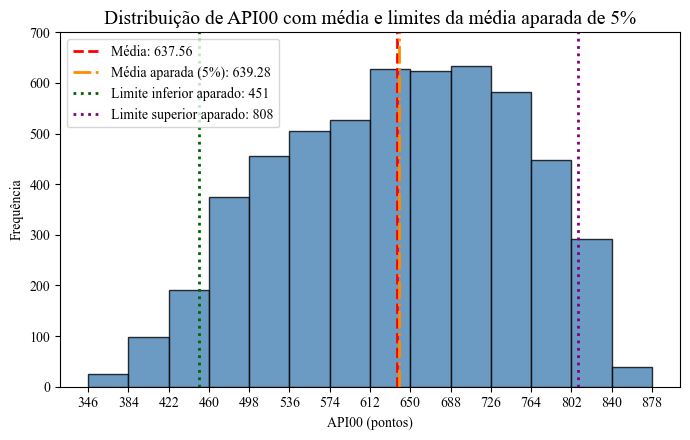

In [135]:
# Histograma de API00 com média e limites da média aparada
# Cálculo do número de classes para o histograma
bins_sturges = int(np.ceil(np.log2(n_total) + 1))

# Cálculo da largura da classe (k)
k = (api00.max() - api00.min()) / bins_sturges

# Limites válidos após aparar 5% em cada cauda
limite_inferior = valores_ordenados[v]
limite_superior = valores_ordenados[n_total - v - 1]

fig, ax = plt.subplots()
# Distribuição de frequências de API00
ax.hist(
    api00,
    bins=bins_sturges,
    color='#4682B4',
    edgecolor='#000000',
    alpha=0.8,
)

# Linhas de referência: média e limites da amostra aparada
ax.axvline(
    media_original,
    color='#FF0000',
    linestyle='--',
    linewidth=2,
    label=f'Média: {media_original:.2f}',
)
ax.axvline(
    media_aparada,
    color='#FF8C00',
    linestyle='-.',
    linewidth=2,
    label=f'Média aparada ({trim_pct*100:.0f}%): {media_aparada:.2f}',
)
ax.axvline(
    limite_inferior,
    color='#006400',
    linestyle=':',
    linewidth=2,
    label=f'Limite inferior aparado: {limite_inferior:.0f}',
)
ax.axvline(
    limite_superior,
    color='#800080',
    linestyle=':',
    linewidth=2,
    label=f'Limite superior aparado: {limite_superior:.0f}',
)

# Elementos de apresentação do gráfico
ax.set_title(
    f'Distribuição de API00 com média e limites da média aparada de {trim_pct*100:.0f}%'
)
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Frequência')
xticks = np.arange(api00.min(), api00.max() + k, k)
ax.set_xticks(xticks)
ymax = ax.get_ylim()[1]
yticks = np.arange(0, int(ymax) + 101, 100)
ax.set_yticks(yticks)
ax.legend()
plt.tight_layout()
plt.show()


***Fig. 2 - Distribuição de API00 com média e limites da média aparada de 5%**. O histograma apresenta forma aproximadamente simétrica, com **leve assimetria à esquerda**, e a proximidade entre média original e média aparada indica baixa influência dos extremos no valor central. Nos dados observados, a média original é **637,56** e a média aparada é **639,28**, com diferença de apenas **+1,72 ponto**, reforçando o efeito pequeno das caudas. Fonte: Carubbi, 2026.*


Assim, a **média isolada** pode esconder diferenças importantes entre escolas; por isso, ela deve ser interpretada junto com outras **medidas de resumo**.

Neste caso, a média aparada permanece muito próxima da média original. A diferença observada (**+1,72** ponto) indica **efeito pequeno** dos valores nas caudas da distribuição sobre a média. Portanto, ao reduzir **5%** dos valores extremos em cada cauda, observa-se que os extremos não afetam de forma relevante o valor médio de `API00`.

#### **Média Geométrica**


Ao estudar fenômenos como inflação ou crescimento populacional, que envolvem aumentos ou reduções periódicas (taxas de variação), a **média geométrica** é mais adequada para determinar a variação média ao longo do período analisado.

Para uma sequência com **$n$** valores positivos $x_1, x_2, \ldots, x_n$, a média geométrica pode ser escrita como:

$$
\bar{x}_{geo} = \sqrt[n]{x_1 \cdot x_2 \cdot \ldots \cdot x_n} \tag{4}
$$

ou, de forma equivalente:

$$
\bar{x}_{geo} = \left(\prod_{i=1}^{n} x_i\right)^{\frac{1}{n}}, \quad \forall i,\; x_i > 0,\; n \ge 1. \tag{5}
$$


onde $\prod_{i=1}^{n} x_i$ indica que os valores são combinados por multiplicação, e $n$ representa o número de observações, sendo utilizado como o índice da raiz que normaliza o produto para a escala original dos dados.


##### **Exemplo 2**

Considere o conjunto de dados `api.csv` e defina, para cada escola, o fator de variação:

$$
r_i = \frac{API00_i}{API99_i}
$$

A média geométrica de $r_i$ resume a **variação multiplicativa média** entre 1999 e 2000.

a. Extraia os pares válidos em que `API00 > 0` e `API99 > 0`, calcule $r_i$ e determine o tamanho da amostra ($n$).  
b. Implemente uma **função em Python** para média geométrica amostral (sem usar função pronta específica de média geométrica).  
c. Use a função implementada no item (b) para calcular a média geométrica de $r_i$.  
d. Calcule a média geométrica de $r_i$ usando a função `stats.gmean` e compare com o resultado da sua função.  
e. **Interprete** o resultado no contexto da variação média do desempenho das escolas entre 1999 e 2000.


##### **Resposta**


In [136]:
# Item (a): construir r_i e determinar n
mask_geo = (df['API00'] > 0) & (df['API99'] > 0)
r = (df.loc[mask_geo, 'API00'] / df.loc[mask_geo, 'API99']).dropna()
n_r = len(r)

print(f'Tamanho da amostra (n): {n_r}')
print('Primeiros 10 valores de r_i:')
print(r.head(10))


Tamanho da amostra (n): 5423
Primeiros 10 valores de r_i:
0    1.054834
1    1.056027
2    1.087413
3    1.057377
4    1.034439
5    1.075862
6    1.056209
7    1.107946
8    1.003788
9    1.120690
dtype: float64


In [137]:
# Item (b): função de média geométrica amostral (fórmula 5)
def media_geometrica(valores):
    valores = np.asarray(valores, dtype=float)
    if valores.size == 0:
        raise ValueError('A amostra não pode ser vazia.')
    if np.any(valores <= 0):
        raise ValueError('Todos os valores devem ser positivos.')

    n = valores.size
    produto = np.prod(valores)
    return produto ** (1 / n)


In [138]:
# Item (c): média geométrica com função própria
media_geo_func = media_geometrica(r)
print(f'Média geométrica (função própria): {media_geo_func:.6f} (adimensional)')


Média geométrica (função própria): 1.060215 (adimensional)


In [139]:
# Item (d): comparação usando apenas stats.gmean
media_geo_func = media_geometrica(r)
media_geo_scipy = stats.gmean(r)
dif_geom = abs(media_geo_func - media_geo_scipy)

print(f'Média geométrica (função própria): {media_geo_func:.6f} (adimensional)')
print(f'Média geométrica (stats.gmean): {media_geo_scipy:.6f} (adimensional)')
print(f'Diferença absoluta (própria vs scipy): {dif_geom:.12f} (adimensional)')


Média geométrica (função própria): 1.060215 (adimensional)
Média geométrica (stats.gmean): 1.060215 (adimensional)
Diferença absoluta (própria vs scipy): 0.000000000000 (adimensional)


**Item (e) - Interpretação**

Se a média geométrica de $r_i$ for maior que 1, em média houve **crescimento multiplicativo** de `API00` em relação a `API99`; se for menor que 1, houve **redução média**. A variação média percentual pode ser obtida por $(\bar{x}_{geo} - 1) \times 100$.

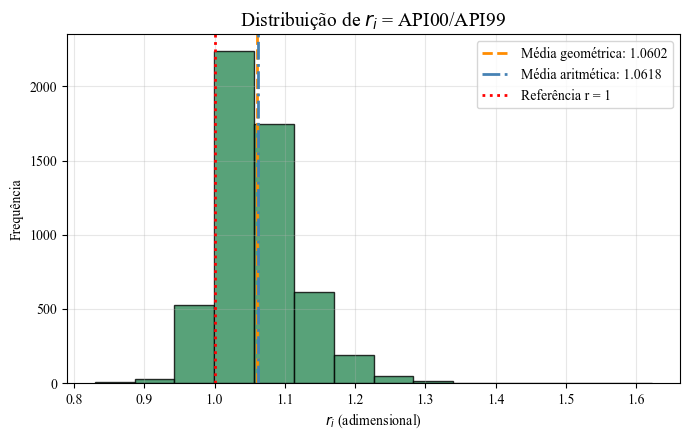

In [166]:
# Gráfico 3: distribuição de r_i com médias geométrica e aritmética
media_geo_r = stats.gmean(r)
media_arit_r = np.mean(r)

fig, ax = plt.subplots()
# Distribuição de frequências de r_i
ax.hist(
    r,
    bins='sturges',
    color='#2E8B57',
    edgecolor='#000000',
    alpha=0.8,
)
# Linhas de referência: média geométrica, média aritmética e r=1
ax.axvline(
    media_geo_r,
    color='#FF8C00',
    linestyle='--',
    linewidth=2,
    label=f'Média geométrica: {media_geo_r:.4f}',
)
ax.axvline(
    media_arit_r,
    color='#4682B4',
    linestyle='-.',
    linewidth=2,
    label=f'Média aritmética: {media_arit_r:.4f}',
)
ax.axvline(
    1.0,
    color='#FF0000',
    linestyle=':',
    linewidth=2,
    label='Referência r = 1',
)
# Elementos de apresentação do gráfico
ax.set_title(r'Distribuição de $r_i$ = API00/API99')
ax.set_xlabel(r'$r_i$ (adimensional)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 3 - Distribuição da razão $r_i = API00/API99$ com média geométrica e referência $r=1$**. A média geométrica posicionada acima de $1$ indica que, em média, houve **crescimento multiplicativo** do desempenho de `API00` em relação a `API99`. No conjunto analisado, $\bar{x}_{geo} \approx 1{,}0602$, o que corresponde a um crescimento médio de aproximadamente **6,02%**. A pequena diferença entre a média geométrica e a média aritmética indica que as razões $r_i$ não estão muito dispersas ou assimétricas. Fonte: Carubbi, 2026.*


#### **Média Harmônica**


A **média harmônica** é mais adequada quando desejamos calcular a média de grandezas inversas, como velocidade (km/h) ou densidade populacional (hab/km²).

Para **$n$** números reais positivos $x_1, x_2, \ldots, x_n$, a média harmônica é definida por:

$$
\bar{x}_{h} = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}, \quad \forall i,\; x_i > 0,\; n \ge 1. \tag{6}
$$

onde $\sum_{i=1}^{n} \frac{1}{x_i}$ representa a soma dos inversos dos valores observados $\left(x_1, x_2, \ldots, x_n\right)$, e $n$ corresponde ao número total de observações consideradas no cálculo, sendo utilizado para obter a taxa média efetiva.


##### **Exemplo 3**

Considere uma aplicação prática de velocidade média em um trajeto com trechos de mesma distância. Nessa situação, a média harmônica é a medida adequada para agregar velocidades.

a. Considere as velocidades (km/h) em quatro trechos de mesma distância: $v = [40, 60, 80, 100]$ e determine o tamanho da amostra ($n$).  
b. Implemente uma função em Python para média harmônica amostral com base na fórmula (6).  
c. Use a função implementada no item (b) para calcular a média harmônica das velocidades.  
d. Calcule a média harmônica usando `stats.hmean` e compare com o resultado da sua função.  
e. Interprete o resultado no contexto da velocidade média em trechos de mesma distância.


##### **Resposta**


In [141]:
# Item (a): definir as velocidades e o tamanho da amostra
velocidades = np.array([40, 60, 80, 100], dtype=float)
n_v = velocidades.size

print(f'Tamanho da amostra (n): {n_v}')
print('Velocidades (km/h):', velocidades)

Tamanho da amostra (n): 4
Velocidades (km/h): [ 40.  60.  80. 100.]


In [142]:
# Item (b): implementar a média harmônica amostral (fórmula 6)
def media_harmonica_amostral(valores):
    valores = np.asarray(valores, dtype=float)
    if valores.size == 0:
        raise ValueError('A amostra não pode ser vazia.')
    if np.any(valores <= 0):
        raise ValueError('Todos os valores devem ser positivos.')

    n = valores.size
    soma_inversos = np.sum(1 / valores)
    return n / soma_inversos

In [143]:
# Item (c): calcular com a função implementada
media_harm_func = media_harmonica_amostral(velocidades)
print(f'Média harmônica (função própria): {media_harm_func:.6f} km/h')


Média harmônica (função própria): 62.337662 km/h


In [144]:
# Item (d): calcular com stats.hmean e comparar resultados
media_harm_func = media_harmonica_amostral(velocidades)
media_harm_scipy = stats.hmean(velocidades)
dif_harm = abs(media_harm_func - media_harm_scipy)

print(f'Média harmônica (stats.hmean): {media_harm_scipy:.6f} km/h')
print(f'Diferença absoluta: {dif_harm:.12f} km/h')


Média harmônica (stats.hmean): 62.337662 km/h
Diferença absoluta: 0.000000000000 km/h


**Item (e) - Interpretação**

Como os trechos têm a mesma distância, a média harmônica representa melhor a velocidade média do percurso. Em geral, esse valor tende a ser menor que a média aritmética das velocidades, refletindo maior influência dos trechos mais lentos no tempo total de viagem.

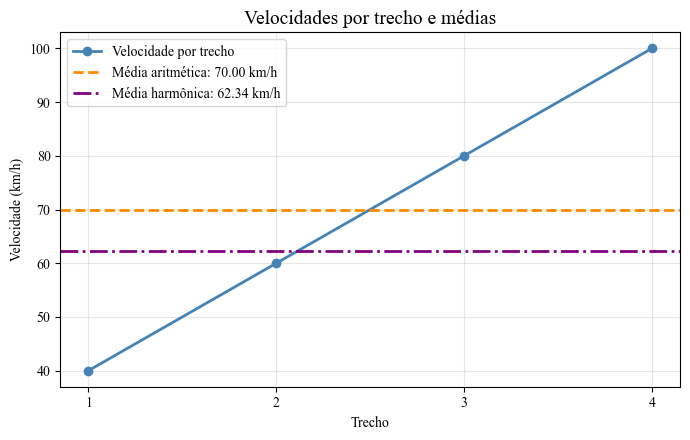

In [145]:
# Gráfico 4: velocidades por trecho e comparação de médias
media_vel_arit = np.mean(velocidades)
media_vel_harm = stats.hmean(velocidades)

fig, ax = plt.subplots()
# Série de velocidades observadas por trecho
ax.plot(
    np.arange(1, n_v + 1),
    velocidades,
    marker='o',
    linewidth=2,
    color='#4682B4',
    label='Velocidade por trecho',
)
# Linhas de referência: média aritmética e média harmônica
ax.axhline(
    media_vel_arit,
    color='#FF8C00',
    linestyle='--',
    linewidth=2,
    label=f'Média aritmética: {media_vel_arit:.2f} km/h',
)
ax.axhline(
    media_vel_harm,
    color='#800080',
    linestyle='-.',
    linewidth=2,
    label=f'Média harmônica: {media_vel_harm:.2f} km/h',
)
# Elementos de apresentação do gráfico
ax.set_title('Velocidades por trecho e médias')
ax.set_xlabel('Trecho')
ax.set_ylabel('Velocidade (km/h)')
ax.set_xticks(np.arange(1, n_v + 1))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 4 - Velocidades por trecho com comparação entre média aritmética e média harmônica**. Para trechos de mesma distância, a média harmônica representa melhor a velocidade média efetiva e evidencia maior sensibilidade aos trechos mais lentos. Nos dados do exemplo ($40$, $60$, $80$ e $100$ km/h), observa-se que a média harmônica (**62,34 km/h**) é menor que a média aritmética (**70,00 km/h**), confirmando a influência dos menores valores no resultado final. Fonte: Carubbi, 2026.*


#### **Média Aritmética Ponderada**


Há aplicações em que determinados valores de um conjunto de dados têm **pesos diferentes**. Para uma sequência com $n$ valores $x_1, x_2, \ldots, x_n$ e pesos $w_1, w_2, \ldots, w_n$, a **média aritmética ponderada** é definida por:

$$
\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}, \quad w_i \ge 0, \; \sum_{i=1}^{n} w_i > 0, \; n \ge 1. \tag{7}
$$


onde $\sum_{i=1}^{n} w_i x_i$ representa a soma dos valores observados ponderados por seus respectivos pesos, e $\sum_{i=1}^{n} w_i$ corresponde à soma total dos pesos, que normaliza o resultado de acordo com a importância relativa de cada observação.

Além disso, $w_i$ é o peso associado ao valor $x_i$, $\bar{x}_w$ é a média aritmética ponderada e $n$ é o número total de observações consideradas.


##### **Exemplo 4**

Considere o conjunto de dados `api.csv` e calcule a **média aritmética ponderada** de `API00`, usando `TEST_NUM` como peso (quantidade de alunos testados por escola).

a. Construa os vetores de valores (`API00`) e pesos (`TEST_NUM`) com dados válidos e determine o tamanho da amostra.  
b. Implemente uma função em Python para média aritmética ponderada com base na fórmula (7).  
c. Use a função implementada no item (b) para calcular a média ponderada de `API00`.  
d. Calcule a média ponderada com `numpy` (`np.average`) e compare com o resultado da sua função.  
e. Interprete o resultado no contexto do desempenho médio das escolas quando o peso é o total de alunos testados.


##### **Resposta**


In [146]:
# Item (a): extrair API00 e TEST_NUM válidos e determinar n
mask_pond = df['API00'].notna() & df['TEST_NUM'].notna() & (df['TEST_NUM'] > 0)
api00 = df.loc[mask_pond, 'API00']
pesos = df.loc[mask_pond, 'TEST_NUM']
n_pond = api00.size

print(f'Tamanho da amostra (n): {n_pond} escolas')
print(f'Soma dos pesos: {pesos.sum():.0f} alunos')


Tamanho da amostra (n): 5423 escolas
Soma dos pesos: 2851488 alunos


In [147]:
# Item (b): implementar função de média aritmética ponderada (fórmula 7)
def media_aritmetica_ponderada(valores, pesos):
    valores = np.asarray(valores, dtype=float)
    pesos = np.asarray(pesos, dtype=float)

    if valores.size == 0 or pesos.size == 0:
        raise ValueError('Valores e pesos não podem ser vazios.')
    if valores.size != pesos.size:
        raise ValueError('Valores e pesos devem ter o mesmo tamanho.')
    if np.any(pesos < 0):
        raise ValueError('Os pesos devem ser não negativos.')

    soma_pesos = pesos.sum()
    if soma_pesos <= 0:
        raise ValueError('A soma dos pesos deve ser positiva.')

    soma_ponderada = np.sum(valores * pesos)
    return soma_ponderada / soma_pesos


In [148]:
# Item (c): calcular a média ponderada com a função implementada
media_pond_func = media_aritmetica_ponderada(api00, pesos)
print(f'Média ponderada de API00 (função própria): {media_pond_func:.4f} pontos')


Média ponderada de API00 (função própria): 622.4861 pontos


In [149]:
# Item (d): calcular com numpy e comparar com a função própria
media_pond_np = np.average(api00, weights=pesos)
dif_pond = abs(media_pond_func - media_pond_np)

print(f'Média ponderada de API00 (numpy): {media_pond_np:.4f} pontos')
print(f'Diferença absoluta: {dif_pond:.12f} ponto(s)')


Média ponderada de API00 (numpy): 622.4861 pontos
Diferença absoluta: 0.000000000000 ponto(s)


**Item (e) - Interpretação**

Ao usar `TEST_NUM` como peso, escolas com **maior número de alunos testados** influenciam mais o resultado final. Assim, a média ponderada de `API00` representa o desempenho médio do sistema considerando a participação relativa de estudantes em cada escola.

Em comparação com a **média aritmética simples (637.5611 pontos)** calculada no **Exemplo 1**, a média aritmética ponderada incorpora o tamanho de cada escola por meio de `TEST_NUM`. Assim, quando escolas com maior peso apresentam desempenho diferente da média global, o valor ponderado tende a se deslocar em relação à média simples.


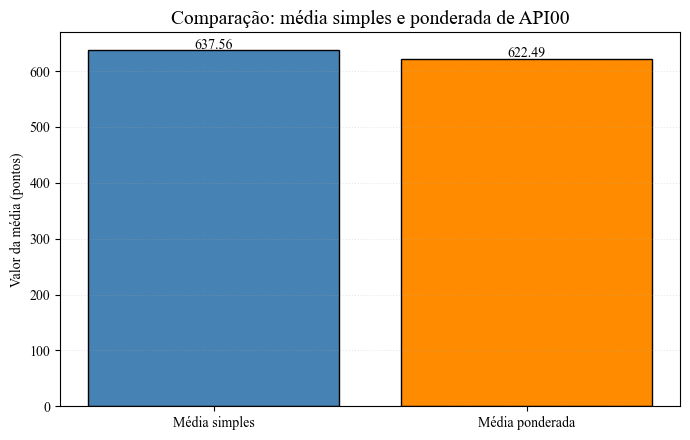

In [150]:
# Gráfico 2: média aritmética simples vs média aritmética ponderada
media_api00_simples = np.mean(api00)
media_api00_pond = np.average(api00, weights=pesos)

fig, ax = plt.subplots()
# Barras comparando as duas médias de API00
ax.bar(
    ['Média simples', 'Média ponderada'],
    [media_api00_simples, media_api00_pond],
    color=['#4682B4', '#FF8C00'],
    edgecolor='#000000',
)
# Linhas/valores de referência exibidos sobre as barras
ax.text(0, media_api00_simples + 2, f'{media_api00_simples:.2f}',
        ha='center')
ax.text(1, media_api00_pond + 2, f'{media_api00_pond:.2f}',
        ha='center')
# Elementos de apresentação do gráfico
ax.set_title('Comparação: média simples e ponderada de API00')
ax.set_ylabel('Valor da média (pontos)')
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 5 - Comparação entre média aritmética simples e média aritmética ponderada de API00**. A diferença entre as barras evidencia o efeito dos pesos (`TEST_NUM`) no valor médio, destacando o impacto relativo de escolas com maior número de alunos testados. Nos dados do notebook, a média simples é **637,56 pontos** e a ponderada é **622,49 pontos**, com redução de **15,08 pontos** quando os pesos são considerados. Fonte: Carubbi, 2026.*


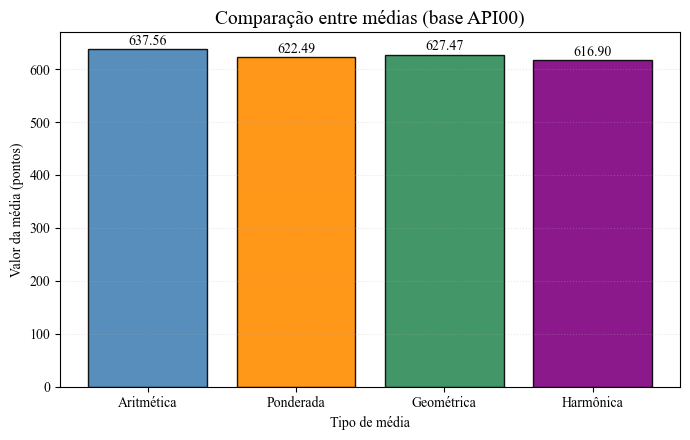

In [151]:
# Gráfico 5: comparação geral entre médias
api00_pos = api00[api00 > 0]
media_arit = np.mean(api00)
media_pond = np.average(api00, weights=pesos)
media_geo_api00 = stats.gmean(api00_pos)
media_harm_api00 = stats.hmean(api00_pos)

rotulos = [
    'Aritmética',
    'Ponderada',
    'Geométrica',
    'Harmônica',
]
valores = [
    media_arit,
    media_pond,
    media_geo_api00,
    media_harm_api00,
]
cores = [
    '#4682B4',
    '#FF8C00',
    '#2E8B57',
    '#800080',
]

fig, ax = plt.subplots()
# Barras com as quatro medidas de tendência central
ax.bar(rotulos, valores, color=cores, edgecolor='#000000', alpha=0.9)
# Linhas/valores de referência exibidos sobre as barras
for i, v in enumerate(valores):
    ax.text(i, v + 2, f'{v:.2f}', ha='center', va='bottom')
# Elementos de apresentação do gráfico
ax.set_title('Comparação entre médias (base API00)')
ax.set_ylabel('Valor da média (pontos)')
ax.set_xlabel('Tipo de média')
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 6 - Comparação geral entre médias: aritmética, ponderada, geométrica e harmônica**. O gráfico resume, em termos **metodológicos**, como diferentes definições de média respondem de forma distinta à distribuição dos dados e ao papel de pesos. Para a variável `API00` (desempenho acadêmico), a interpretação aplicada principal deve priorizar a **média aritmética** e a **média aritmética ponderada**; os valores geométrico e harmônico são apresentados apenas para contraste didático. Fonte: Carubbi, 2026.*


### **Mediana**

Outra medida de tendência central importante é a **mediana**. A mediana é o valor central de um conjunto de dados ordenado em ordem crescente e divide os dados em duas partes de mesmo tamanho.

O cálculo da mediana pode ser organizado em dois passos:
1. Ordenar os dados em ordem crescente.
2. Identificar o(s) termo(s) central(is).

Seja $x_1, x_2, \ldots, x_n$ um conjunto de observações reais e seja $x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}$ a amostra ordenada. A mediana amostral $\tilde{x}$ é definida por:

$$
\tilde{x} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & \text{se } n \text{ é ímpar}, \\[4pt]
\frac{1}{2}\left(x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}\right), & \text{se } n \text{ é par}.
\end{cases} \tag{8}
$$


##### **Exemplo 5**

Considere o conjunto de dados `api.csv` e utilize a variável `TEST_NUM` para calcular a **mediana amostral**.

a. Extraia os valores válidos de `TEST_NUM`, ordene-os e determine o tamanho da amostra ($n$).  
b. Implemente uma função em Python para calcular a mediana amostral com base na fórmula (8), sem usar função pronta de mediana.  
c. Use a função implementada no item (b) para calcular a mediana de `TEST_NUM`.  
d. Calcule a mediana com `numpy` (`np.median`) e com `scipy` (`stats.scoreatpercentile`, percentil 50) e compare com o resultado da sua função.  
e. Interprete o valor encontrado no contexto do número de alunos testados por escola e comente por que a mediana é útil em distribuições assimétricas.


##### **Resposta**


In [152]:
# Item (a): extrair TEST_NUM e determinar n
test_num = df['TEST_NUM'].dropna()
test_num_ord = np.sort(test_num)
n = test_num_ord.size

print(f'Tamanho da amostra (n): {n} escolas')
print('Primeiros 5 valores ordenados (alunos):', test_num_ord[:5])


Tamanho da amostra (n): 5423 escolas
Primeiros 5 valores ordenados (alunos): [100 101 101 101 102]


In [153]:
# Item (b): implementar função de mediana amostral (fórmula 8)
def mediana_amostral(valores):
    valores = np.asarray(valores, dtype=float)
    if valores.size == 0:
        raise ValueError('A amostra não pode ser vazia.')

    valores_ord = np.sort(valores)
    n = valores_ord.size

    if n % 2 == 1:
        return valores_ord[n // 2]

    i_sup = n // 2
    i_inf = i_sup - 1
    return 0.5 * (valores_ord[i_inf] + valores_ord[i_sup])


In [154]:
# Item (c): calcular a mediana com a função implementada
mediana_func = mediana_amostral(test_num)
print(f'Mediana de TEST_NUM (função própria): {mediana_func:.4f} alunos')


Mediana de TEST_NUM (função própria): 405.0000 alunos


In [155]:
# Item (d): calcular com numpy e scipy e comparar com a função própria
mediana_np = np.median(test_num)
mediana_scipy = stats.scoreatpercentile(test_num, 50)
dif_np = abs(mediana_func - mediana_np)
dif_scipy = abs(mediana_func - mediana_scipy)

print(f'Mediana de TEST_NUM (numpy): {mediana_np:.4f} alunos')
print(f'Mediana de TEST_NUM (scipy): {mediana_scipy:.4f} alunos')
print(f'Diferença abs. (função vs numpy): {dif_np:.12f} aluno(s)')
print(f'Diferença abs. (função vs scipy): {dif_scipy:.12f} aluno(s)')


Mediana de TEST_NUM (numpy): 405.0000 alunos
Mediana de TEST_NUM (scipy): 405.0000 alunos
Diferença abs. (função vs numpy): 0.000000000000 aluno(s)
Diferença abs. (função vs scipy): 0.000000000000 aluno(s)


**Item (e) - Interpretação**

A mediana de `TEST_NUM` representa o ponto central do número de alunos testados por escola. Neste conjunto, a mediana é **405,00 alunos**, enquanto a média é **525,81 alunos**, indicando **assimetria à direita** (cauda longa de escolas com muitos alunos testados). Nesse cenário, a mediana é uma medida robusta e descreve melhor o valor típico da distribuição.


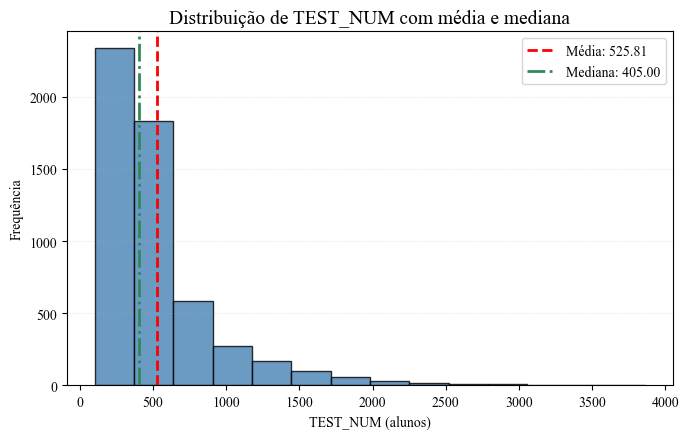

In [156]:
# Histograma de TEST_NUM com média e mediana
# Reaproveita a variável do exercício e calcula medidas para o gráfico
media = np.mean(test_num)
mediana = np.median(test_num)
bins_sturges = int(np.ceil(np.log2(test_num.size) + 1))

fig, ax = plt.subplots()
# Distribuição de frequências de TEST_NUM
ax.hist(
    test_num,
    bins=bins_sturges,
    color='#4682B4',
    edgecolor='#000000',
    alpha=0.8,
)

# Linhas de referência: média e mediana
ax.axvline(
    media,
    color='#FF0000',
    linestyle='--',
    linewidth=2,
    label=f'Média: {media:.2f}',
)
ax.axvline(
    mediana,
    color='#2E8B57',
    linestyle='-.',
    linewidth=2,
    label=f'Mediana: {mediana:.2f}',
)

# Elementos de apresentação do gráfico
ax.set_title('Distribuição de TEST_NUM com média e mediana')
ax.set_xlabel('TEST_NUM (alunos)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 7 - Distribuição de TEST_NUM com média e mediana**. A cauda longa à direita desloca a média para valores maiores, enquanto a mediana permanece mais estável e representativa do valor típico, evidenciando sua robustez em distribuições assimétricas. Fonte: Carubbi, 2026.*


### **Moda**

Em Estatística, a **moda** é o valor que ocorre com maior frequência em um conjunto de dados. Em uma distribuição de frequências, a moda corresponde ao(s) pico(s) do gráfico.

Considere uma amostra $x_1, x_2, \ldots, x_n$ e o conjunto dos valores distintos observados $S=\{v_1, v_2, \ldots, v_k\}$. Defina a frequência absoluta de um valor $v \in S$ por:

$$
f(v)=\sum_{i=1}^{n} \mathbf{1}(x_i=v),
$$

onde $\mathbf{1}(x_i=v)$ é a função indicadora, que vale $1$ quando $x_i=v$ e $0$ caso contrário.

A **moda** é definida como o conjunto dos valores que maximizam a frequência:

$$
\operatorname{Mo}(X)=\arg\max_{v \in S} f(v). \tag{9}
$$

Quando existe uma única moda, a distribuição é **unimodal**. Quando existem duas modas, é **bimodal**. Se houver mais de duas modas, é **multimodal**. Também pode ocorrer de não haver moda (por exemplo, quando todos os valores aparecem com a mesma frequência).

<p align="center">
  <img src="imgs/modes.png" width="850">
</p>

***Fig. 8 - Padrões de moda em distribuições: unimodal, bimodal e multimodal**. A figura ilustra que a moda corresponde aos picos de frequência e pode assumir um, dois ou mais valores, dependendo da forma da distribuição. Fonte: Adaptado de Freie Universität Berlin, SOGA – The Mode.*

##### **Exemplo 6**

Considere o conjunto de dados `api.csv` e utilize a variável `API00` para calcular a **moda amostral**.

a. Extraia os valores válidos de `API00` e determine o tamanho da amostra ($n$).  
b. Implemente uma função em Python para calcular a moda amostral com base na fórmula (9), retornando o(s) valor(es) modal(is) e a frequência máxima.  
c. Use a função implementada no item (b) para calcular a moda de `API00`.  
d. Calcule a moda com `numpy` (`np.unique` com `return_counts=True`) e compare com o resultado da sua função.  
e. Interprete o valor encontrado no contexto do desempenho das escolas e compare com média e mediana já calculadas.


##### **Resposta**


In [157]:
# Item (a): extrair API00 e determinar n
api00 = df['API00'].dropna()
n = api00.size

print(f'Tamanho da amostra (n): {n} escolas')

Tamanho da amostra (n): 5423 escolas


In [158]:
# Item (b): implementar função de moda amostral (fórmula 9)
def moda_amostral(valores):
    valores = list(valores)
    if len(valores) == 0:
        raise ValueError('A amostra não pode ser vazia.')

    frequencias = {}
    for v in valores:
        frequencias[v] = frequencias.get(v, 0) + 1

    freq_max = max(frequencias.values())
    modos = [v for v, f in frequencias.items() if f == freq_max]
    modos.sort()
    return modos, int(freq_max)


In [159]:
# Item (c): calcular a moda com a função implementada
modos_api00_func, freq_max_api00 = moda_amostral(api00)
print(f'Moda(s) de API00 (função própria): {modos_api00_func}')
print(f'Frequência máxima: {freq_max_api00} escolas')


Moda(s) de API00 (função própria): [655]
Frequência máxima: 29 escolas


In [160]:
# Item (d): calcular com numpy e comparar com a função própria
distintos, contagens = np.unique(api00, return_counts=True)
freq_max_np = int(contagens.max())
modos_api00_np = distintos[contagens == freq_max_np].tolist()

coincide_valor = set(modos_api00_np) == set(modos_api00_func)
dif_freq = abs(freq_max_api00 - freq_max_np)

print(f'Moda(s) de API00 (numpy): {modos_api00_np}')
print(f'Frequência máxima (numpy): {freq_max_np} escolas')
print(f'Modos coincidem com a função própria: {coincide_valor}')
print(f'Diferença de frequência: {dif_freq} escola(s)')


Moda(s) de API00 (numpy): [655]
Frequência máxima (numpy): 29 escolas
Modos coincidem com a função própria: True
Diferença de frequência: 0 escola(s)


**Item (e) - Interpretação**

A moda de `API00` identifica o valor mais frequente de desempenho no conjunto de escolas. Neste caso, a moda é **655 pontos** com **29 ocorrências**. Em comparação, a média (**637,56 pontos**) e a mediana (**645,00 pontos**) resumem a tendência central global, enquanto a moda destaca o valor pontual mais recorrente na distribuição.


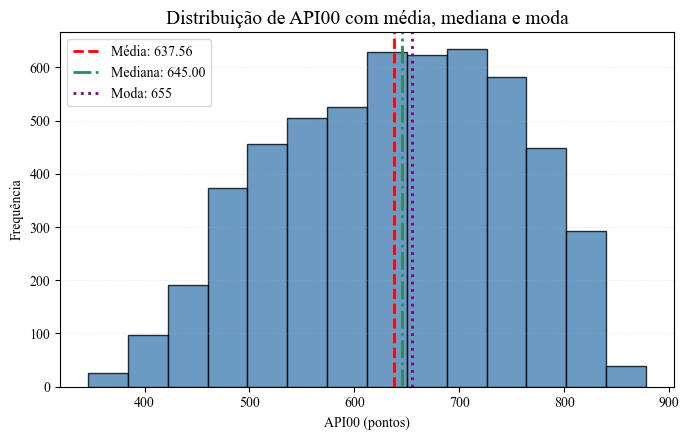

In [161]:
# Histograma de API00 com média, mediana e moda
# Recalcula as medidas com numpy para a figura
media_api00 = np.mean(api00)
mediana_api00 = np.median(api00)
distintos, contagens = np.unique(api00, return_counts=True)
freq_max_plot = contagens.max()
moda_api00 = distintos[contagens == freq_max_plot]

# Distribuição de frequências de API00
bins_sturges = int(np.ceil(np.log2(api00.size) + 1))
fig, ax = plt.subplots()
ax.hist(
    api00,
    bins=bins_sturges,
    color='#4682B4',
    edgecolor='#000000',
    alpha=0.8,
)

# Linhas de referência: média, mediana e moda(s)
ax.axvline(
    media_api00,
    color='#FF0000',
    linestyle='--',
    linewidth=2,
    label=f'Média: {media_api00:.2f}',
)
ax.axvline(
    mediana_api00,
    color='#2E8B57',
    linestyle='-.',
    linewidth=2,
    label=f'Mediana: {mediana_api00:.2f}',
)
for i, m in enumerate(moda_api00):
    rotulo = f'Moda: {int(m)}' if i == 0 else None
    ax.axvline(
        m,
        color='#800080',
        linestyle=':',
        linewidth=2,
        label=rotulo,
    )

# Elementos de apresentação do gráfico
ax.set_title('Distribuição de API00 com média, mediana e moda')
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 9 - Distribuição de API00 com média, mediana e moda**. A proximidade entre as três medidas indica concentração consistente da tendência central, com leve assimetria à esquerda sugerida pela ordem média, mediana e moda. Neste conjunto, as três medidas ficam relativamente próximas (**média = 637,56**, **mediana = 645,00**, **moda = 655**). Isso sugere que a distribuição de `API00` não é fortemente assimétrica, embora a ordem **média < mediana < moda** indique **leve assimetria à esquerda**. Em termos práticos, as três medidas apontam para uma região central semelhante de desempenho das escolas. Fonte: Carubbi, 2026.*


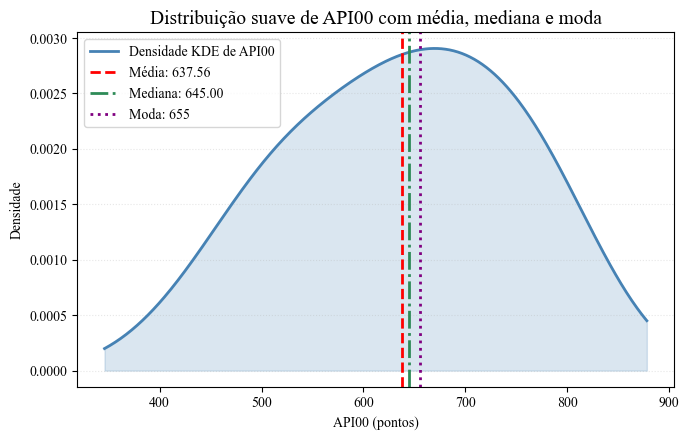

In [165]:
# Densidade suave de API00 com média, mediana e moda
# Recalcula medidas de tendência central de API00
media_api00 = np.mean(api00)
mediana_api00 = np.median(api00)
moda_api00 = int(stats.mode(api00, keepdims=False).mode)

# Estimação da densidade por kernel gaussiano (KDE)
# Curva KDE com banda maior para maior suavização
x = api00.to_numpy()
kde = stats.gaussian_kde(x, bw_method=0.5)
xs = np.linspace(x.min(), x.max(), 400)
ys = kde(xs)

fig, ax = plt.subplots()
# Curva suave da distribuição de API00
ax.plot(
    xs,
    ys,
    color='#4682B4',
    linewidth=2,
    label='Densidade KDE de API00',
)

# Preenchimento da área sob a curva de densidade
ax.fill_between(
    xs,
    ys,
    color='#4682B4',
    alpha=0.20,
)

# Linhas de referência: média, mediana e moda
ax.axvline(
    media_api00,
    color='#FF0000',
    linestyle='--',
    linewidth=2,
    label=f'Média: {media_api00:.2f}',
)
ax.axvline(
    mediana_api00,
    color='#2E8B57',
    linestyle='-.',
    linewidth=2,
    label=f'Mediana: {mediana_api00:.2f}',
)
ax.axvline(
    moda_api00,
    color='#800080',
    linestyle=':',
    linewidth=2,
    label=f'Moda: {moda_api00}',
)

# Elementos de apresentação do gráfico
ax.set_title('Distribuição suave de API00 com média, mediana e moda')
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Densidade')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()


***Fig. 10 - Distribuição suave de API00 (KDE) com média, mediana e moda**. A curva KDE representa a densidade estimada de `API00` sem as oscilações das barras do histograma, destacando a forma global da distribuição. No conjunto analisado, o pico da densidade ocorre na faixa central próxima da moda (**655**), e as caudas mostram redução gradual da densidade para valores extremos. Como a área total sob a curva é 1, o eixo vertical expressa **intensidade de probabilidade** (densidade), e não frequência absoluta. Fonte: Carubbi, 2026.*


## **Saiba mais**
1. [Tendência Central](https://en.wikipedia.org/wiki/Central_tendency)
2. [Média](https://en.wikipedia.org/wiki/Arithmetic_mean)
3. [Mediana](https://en.wikipedia.org/wiki/Median)
4. [Moda](https://en.wikipedia.org/wiki/Mode_(statistics))
5. [Média Harmônica](https://en.wikipedia.org/wiki/Harmonic_mean)
6. [Média Ponderada](https://en.wikipedia.org/wiki/Weighted_arithmetic_mean)
7. [Função Densidade de Probabilidade](https://en.wikipedia.org/wiki/Probability_density_function)
8. [Kernel Density Estimation (KDE)](https://en.wikipedia.org/wiki/Kernel_density_estimation)


## **Citação**

Estas aulas são baseadas no projeto de e-learning [SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/index.html) que foi desenvolvido no Departamento de Ciências da Terra por Annette Rudolph, Joachim Krois e Kai Hartmann. O contato pode ser realizado por e-mail, pelo endereço [soga[at]zedat.fu-berlin.de](soga[at]zedat.fu-berlin.de).

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Attribution-ShareAlike 4.0 International. 

Por favor, cite da seguinte forma: Rudolph, A., Krois, J., Hartmann, K. (2023): Estatística e Análise de Geodados usando Python (SOGA-Py). Departamento de Ciências da Terra, Universidade Livre de Berlim.